In [2]:
%pip install xgboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 5.9 MB/s  0:00:005.6 MB/s eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]━━━━━━━━━━━━━ 2/3 [shap]
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
import shap

PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "output"

df = pd.read_csv(DATA_DIR / "analysis_data.csv")

print("Rows:", len(df))
print("Countries:", df["Entity"].nunique())

Rows: 1092
Countries: 52


In [4]:
features = [
    "resource_rents",
    "log_gdp_pc",
    "electricity_access",
    "Year"
]

target = "water_access"

train = df[df["Year"] <= 2017].copy()
test = df[df["Year"] >= 2018].copy()

print("Training observations:", len(train))
print("Test observations:", len(test))

Training observations: 888
Test observations: 204


In [5]:
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(train[features]),
    columns=features,
    index=train.index
)

X_test = pd.DataFrame(
    scaler.transform(test[features]),
    columns=features,
    index=test.index
)

y_train = train[target]
y_test = test[target]

In [6]:
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.90,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)

print("XGBoost model fitted.")

XGBoost model fitted.


In [7]:
train_pred = xgb.predict(X_train)
test_pred = xgb.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

print("XGBOOST PERFORMANCE")
print("-------------------")
print("Train R²:", round(train_r2, 3))
print("Test R²:", round(test_r2, 3))
print("Train RMSE:", round(train_rmse, 2))
print("Test RMSE:", round(test_rmse, 2))

XGBOOST PERFORMANCE
-------------------
Train R²: 0.936
Test R²: 0.671
Train RMSE: 4.59
Test RMSE: 8.99


In [8]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values created.")
print("Shape:", shap_values.shape)

SHAP values created.
Shape: (204, 4)


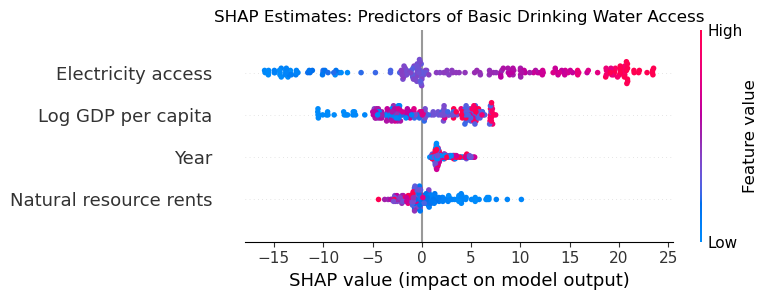

In [9]:
X_test_plot = X_test.rename(columns={
    "resource_rents": "Natural resource rents",
    "log_gdp_pc": "Log GDP per capita",
    "electricity_access": "Electricity access",
    "Year": "Year"
})

shap.summary_plot(
    shap_values,
    X_test_plot,
    show=False
)

plt.title("SHAP Estimates: Predictors of Basic Drinking Water Access")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "SHAPEstimate_Burkina.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
mean_shap = np.abs(shap_values).mean(axis=0)

importance = pd.DataFrame({
    "feature": X_test_plot.columns,
    "mean_absolute_shap": mean_shap
}).sort_values(
    "mean_absolute_shap",
    ascending=False
)

display(importance)

,feature,mean_absolute_shap
2,Electricity access,10.314470
1,Log GDP per capita,4.082726
3,Year,2.146820
0,Natural resource rents,1.717658


In [11]:
performance = pd.DataFrame({
    "model": ["XGBoost"],
    "train_r2": [train_r2],
    "test_r2": [test_r2],
    "train_rmse": [train_rmse],
    "test_rmse": [test_rmse]
})

performance.to_csv(
    OUTPUT_DIR / "xgboost_performance.csv",
    index=False
)

importance.to_csv(
    OUTPUT_DIR / "shap_importance.csv",
    index=False
)

display(performance)

,model,train_r2,test_r2,train_rmse,test_rmse
0,XGBoost,0.935882,0.671156,4.585835,8.985458


In [12]:
features = [
    "resource_rents",
    "log_gdp_pc",
    "electricity_access",
    "Year"
]

target = "water_access"

train = df[df["Year"] <= 2017].copy()
test = df[df["Year"] >= 2018].copy()

print("Training observations:", len(train))
print("Test observations:", len(test))

Training observations: 888
Test observations: 204


In [13]:
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(train[features]),
    columns=features,
    index=train.index
)

X_test = pd.DataFrame(
    scaler.transform(test[features]),
    columns=features,
    index=test.index
)

y_train = train[target]
y_test = test[target]

In [14]:
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.90,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)

print("XGBoost model fitted.")

XGBoost model fitted.


In [15]:
train_pred = xgb.predict(X_train)
test_pred = xgb.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

print("XGBOOST PERFORMANCE")
print("-------------------")
print("Train R²:", round(train_r2, 3))
print("Test R²:", round(test_r2, 3))
print("Train RMSE:", round(train_rmse, 2))
print("Test RMSE:", round(test_rmse, 2))

XGBOOST PERFORMANCE
-------------------
Train R²: 0.936
Test R²: 0.671
Train RMSE: 4.59
Test RMSE: 8.99


In [16]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values created.")
print("Shape:", shap_values.shape)

SHAP values created.
Shape: (204, 4)


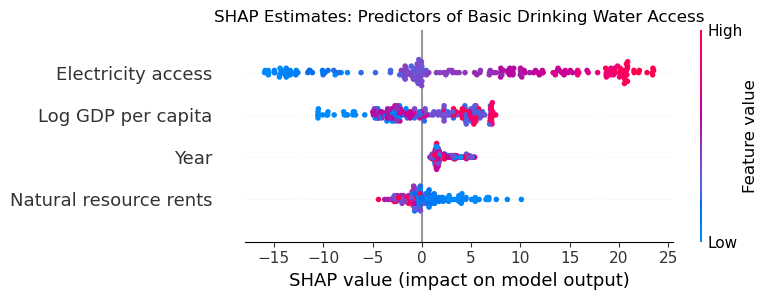

In [17]:
X_test_plot = X_test.rename(columns={
    "resource_rents": "Natural resource rents",
    "log_gdp_pc": "Log GDP per capita",
    "electricity_access": "Electricity access",
    "Year": "Year"
})

shap.summary_plot(
    shap_values,
    X_test_plot,
    show=False
)

plt.title("SHAP Estimates: Predictors of Basic Drinking Water Access")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "SHAPEstimate_Burkina.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
mean_shap = np.abs(shap_values).mean(axis=0)

importance = pd.DataFrame({
    "feature": X_test_plot.columns,
    "mean_absolute_shap": mean_shap
}).sort_values(
    "mean_absolute_shap",
    ascending=False
)

display(importance)

,feature,mean_absolute_shap
2,Electricity access,10.314470
1,Log GDP per capita,4.082726
3,Year,2.146820
0,Natural resource rents,1.717658


In [19]:
performance = pd.DataFrame({
    "model": ["XGBoost"],
    "train_r2": [train_r2],
    "test_r2": [test_r2],
    "train_rmse": [train_rmse],
    "test_rmse": [test_rmse]
})

performance.to_csv(
    OUTPUT_DIR / "xgboost_performance.csv",
    index=False
)

importance.to_csv(
    OUTPUT_DIR / "shap_importance.csv",
    index=False
)

print("Saved:", OUTPUT_DIR / "xgboost_performance.csv")
print("Saved:", OUTPUT_DIR / "shap_importance.csv")

display(performance)

Saved: /Users/melqueso/Documents/QSS45-final-project/output/xgboost_performance.csv
Saved: /Users/melqueso/Documents/QSS45-final-project/output/shap_importance.csv


,model,train_r2,test_r2,train_rmse,test_rmse
0,XGBoost,0.935882,0.671156,4.585835,8.985458
